In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [3]:
df.isnull().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [4]:
(df.isnull().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64

In [5]:
(df.isnull().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64

In [6]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73


In [7]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [8]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [9]:
df["Date"].dt.year

0       2015
1       2015
2       2015
3       2015
4       2015
        ... 
4103    2026
4104    2026
4105    2026
4106    2026
4107    2026
Name: Date, Length: 4108, dtype: int32

In [10]:
df["Date"].dt.year

0       2015
1       2015
2       2015
3       2015
4       2015
        ... 
4103    2026
4104    2026
4105    2026
4106    2026
4107    2026
Name: Date, Length: 4108, dtype: int32

In [11]:
df.columns

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Date', 'Year', 'Month'],
      dtype='str')

In [12]:
df["Date"] = pd.to_datetime(
    df["YEAR"].astype(str) + df["DOY"].astype(str).str.zfill(3),
    format="%Y%j"
)

In [13]:
df[["YEAR", "DOY", "Date"]].head()

,YEAR,DOY,Date
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


In [14]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [15]:
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4108 non-null   int64         
 1   DOY          4108 non-null   int64         
 2   T2M          4108 non-null   float64       
 3   T2M_MAX      4108 non-null   float64       
 4   T2M_MIN      4108 non-null   float64       
 5   T2M_RANGE    4108 non-null   float64       
 6   PRECTOTCORR  4108 non-null   float64       
 7   RH2M         4108 non-null   float64       
 8   WS2M         4108 non-null   float64       
 9   WS2M_MAX     4108 non-null   float64       
 10  PS           4108 non-null   float64       
 11  QV2M         4108 non-null   float64       
 12  Date         4108 non-null   datetime64[us]
 13  Year         4108 non-null   int32         
 14  Month        4108 non-null   int32         
dtypes: datetime64[us](1), float64(10), int32(2), int64(2)
memory usage

In [16]:
df["Date"] = pd.to_datetime(
    df["YEAR"].astype(str) + df["DOY"].astype(str).str.zfill(3),
    format="%Y%j"
)

In [17]:
df[["YEAR", "DOY", "Date"]].head()

,YEAR,DOY,Date
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


In [18]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,2015-01-01,2015,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,2015-01-02,2015,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,2015-01-03,2015,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,2015-01-04,2015,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,2015-01-05,2015,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,2026-03-27,2026,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,2026-03-28,2026,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,2026-03-29,2026,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,2026-03-30,2026,3


In [19]:
df.isnull().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Date           0
Year           0
Month          0
dtype: int64

In [20]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,2020.131451,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,2015.000000,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,2017.000000,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,2020.000000,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,2023.000000,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,2026.000000,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.248907,3.477046


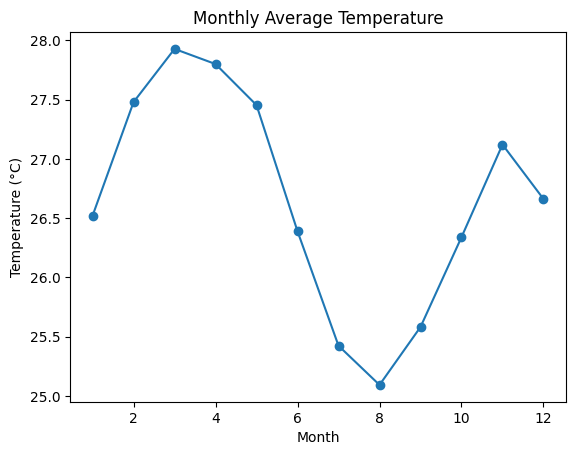

In [21]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

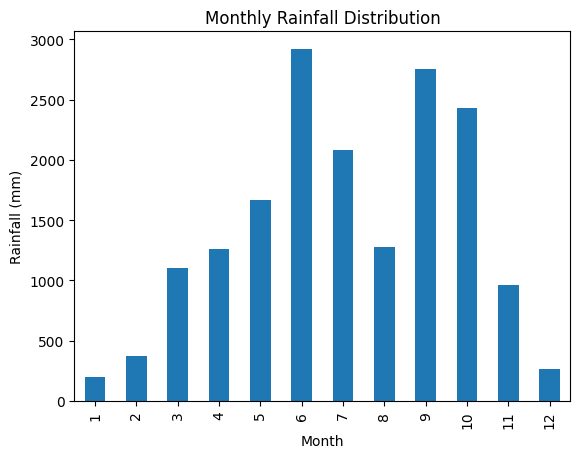

In [22]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall Distribution")
plt.ylabel("Rainfall (mm)")
plt.show()

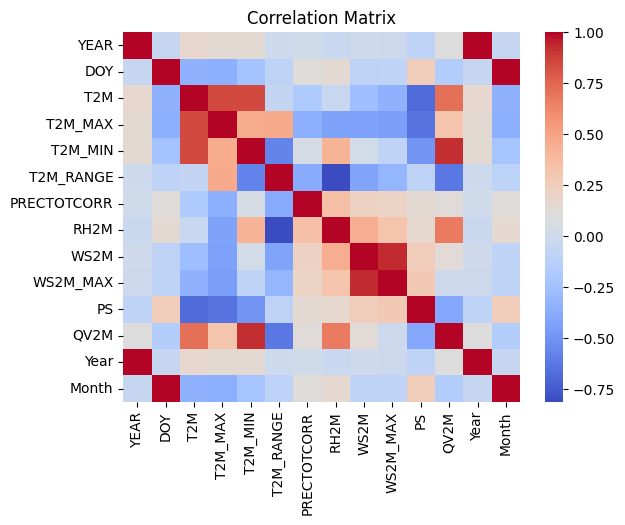

In [23]:
corr = df.corr(numeric_only=True)

import seaborn as sns

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

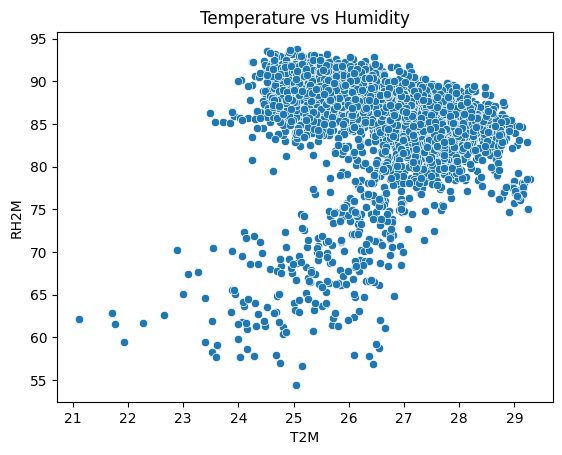

In [24]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.title("Temperature vs Humidity")
plt.show()

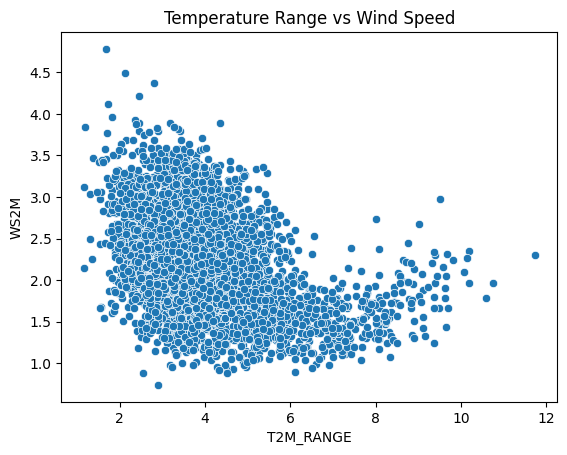

In [25]:
sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.title("Temperature Range vs Wind Speed")
plt.show()

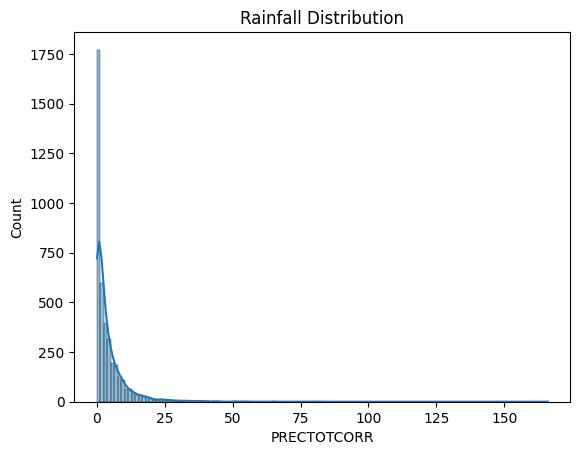

In [26]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.title("Rainfall Distribution")
plt.show()

In [27]:
df = df.replace(-999, np.nan)

In [28]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent.sort_values(ascending=False)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Date           0.0
Year           0.0
Month          0.0
dtype: float64